# Exploring jumps in CDS, Oil, and MSCI time series

 Methodology: Characterizing Jumps via GARCH(1,1) vs. GARCH(1,1)-Jump


 - Compute log returns in time series
 - Estimate plain Garch(1,1) and check residuals
 - Estimate GARCH(1,1)-Jump and check residuals
 - Compare both models through the likelihood ratio

## 2. Estimate the Plain GARCH(1,1)

We fit the standard GARCH(1,1) model, which captures volatility clustering through a smooth persistent variance process.

**Mean equation:**

$$r_t = \mu + \varepsilon_t, \quad \varepsilon_t = \sqrt{h_t} \cdot z_t, \quad z_t \sim N(0,1)$$

**Variance equation:**

$$h_t = \omega + \alpha \, \varepsilon_{t-1}^2 + \beta \, h_{t-1}$$

The parameter set is $\{\mu, \omega, \alpha, \beta\}$, estimated via maximum likelihood. We store:

- The maximized log-likelihood $\mathcal{L}_{\text{GARCH}}$
- The parameter estimates $\{\hat{\mu}, \hat{\omega}, \hat{\alpha}, \hat{\beta}\}$
- The standardized residuals $\hat{z}_t = \varepsilon_t / \sqrt{h_t}$

**Diagnostic checks on residuals:**

- Kurtosis (expect > 3 if jumps are present)
- Jarque-Bera test for normality
- QQ-plot against the normal distribution

If the series contains genuine jumps, the plain GARCH must absorb extreme observations by inflating $\alpha$, and the residuals will exhibit fat tails.

---

## 3. Estimate the GARCH(1,1)-Jump Model

We augment the model by decomposing returns into a smooth (continuous) component and a discrete jump component.

**Mean equation:**

$$r_t = \mu + \sqrt{h_t} \cdot z_t + \sum_{k=1}^{n_t} J_{t,k}$$

where:

- $n_t \sim \text{Poisson}(\lambda)$ is the number of jumps at time $t$
- Each jump $J_{t,k} \sim N(\theta, \delta^2)$ with mean $\theta$ and variance $\delta^2$
- $z_t \sim N(0,1)$ is the continuous innovation

**Variance equation (same structure):**

$$h_t = \omega + \alpha \, \varepsilon_{t-1}^2 + \beta \, h_{t-1}$$

where $\varepsilon_{t-1}$ now refers only to the continuous innovation, not the total return surprise. The parameter set expands to $\{\mu, \omega, \alpha, \beta, \lambda, \theta, \delta^2\}$ — three additional parameters.

**Likelihood function:**

Since we do not observe whether a jump occurred at time $t$, we sum over the Poisson-weighted possibilities. The density of $r_t$ conditional on the information set $\mathcal{F}_{t-1}$ is:

$$f(r_t \mid \mathcal{F}_{t-1}) = \sum_{j=0}^{J_{\max}} \frac{e^{-\lambda} \lambda^j}{j!} \cdot \frac{1}{\sqrt{h_t + j\delta^2}} \cdot \phi\!\left(\frac{r_t - \mu - j\theta}{\sqrt{h_t + j\delta^2}}\right)$$

where $\phi(\cdot)$ is the standard normal density. We truncate at $J_{\max} = 10$ since the Poisson probability of more jumps per period is negligible at weekly frequency.

The total log-likelihood is:

$$\mathcal{L}_{\text{GARCH-J}} = \sum_{t=1}^{T} \ln \, f(r_t \mid \mathcal{F}_{t-1})$$

maximized over all seven parameters using numerical optimization.

---

## 4. Compare the Two Models

Since the plain GARCH is nested within the GARCH-Jump model (set $\lambda = 0$), we use the following comparisons:

### 4a. Likelihood Ratio Test

$$LR = 2\left(\mathcal{L}_{\text{GARCH-J}} - \mathcal{L}_{\text{GARCH}}\right) \sim \chi^2(3)$$

The three degrees of freedom correspond to the three extra parameters $(\lambda, \theta, \delta^2)$. We reject the null of no jumps if $LR > 7.81$ at the 5% level.

*Note:* Testing $\lambda = 0$ lies on the boundary of the parameter space, which can affect the asymptotic distribution. The standard $\chi^2$ test serves as a reasonable approximation and we note this caveat.

### 4b. Information Criteria

$$\text{AIC} = -2\mathcal{L} + 2k, \quad \text{BIC} = -2\mathcal{L} + k \ln T$$

where $k$ is the number of parameters and $T$ is the sample size. If the GARCH-Jump model achieves lower AIC/BIC despite the penalty for extra parameters, the evidence for jumps is robust.

### 4c. Parameter Shifts

We compare $\hat{\alpha}$ across the two models. If jumps are genuinely present, we expect:

$$\hat{\alpha}_{\text{GARCH-J}} < \hat{\alpha}_{\text{GARCH}}$$

because the extreme observations that were inflating $\alpha$ are now absorbed by the jump component. The smooth volatility becomes calmer and more persistent.

### 4d. Residual Improvement

We check whether the standardized residuals from the GARCH-Jump model are closer to normal: reduced kurtosis, improved QQ-plot, and a Jarque-Bera statistic closer to zero.

---

## 5. Extract Jump Parameters

From the estimated GARCH-Jump model, we obtain the three jump parameters that feed directly into the CCA model extension:

| Parameter | Interpretation | Example |
|-----------|---------------|---------|
| $\hat{\lambda}$ | Jump intensity (avg. jumps per period) | $\hat{\lambda} = 0.05$ → one jump every ~20 weeks |
| $\hat{\theta}$ | Mean jump size | Negative for oil crash dynamics |
| $\hat{\delta}^2$ | Jump size variance | Dispersion of jump magnitudes |

These map directly into the sovereign asset process of the extended CCA model:

$$dA = \mu_A \cdot A \cdot dt + \sigma_A \cdot A \cdot dW + J \cdot A \cdot dN$$

where $N$ is a Poisson process with intensity $\lambda$ and $J \sim N(\theta, \delta^2)$.

---

## 6. Cross-Country Comparison

We repeat the full estimation (Steps 2–5) for:

- The **oil price series** (Brent) — to extract "oil jump parameters"
- Each **sovereign CDS spread series** — to extract country-level jump parameters

The key comparison across the oil-exporter and control groups:

| Metric | Oil Exporters vs. Controls |
|--------|---------------------------|
| Likelihood improvement | Larger $LR$ statistic for oil exporters? |
| Jump intensity $\hat{\lambda}$ | Higher for oil exporters? |
| Jump magnitude $|\hat{\theta}|$ | Larger for oil exporters? |
| $\alpha$ reduction | More dramatic drop for oil exporters? |
| Resemblance to oil jumps | Do sovereign jump parameters of oil exporters mirror oil jump parameters? |

This cross-country comparison constitutes the first layer of the difference-in-differences argument, established at the empirical characterization stage before proceeding to the structural CCA model.

## Imports

In [ ]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from scipy.stats import poisson, norm, chi2, fisher_exact, ttest_ind, mannwhitneyu
from scipy.special import gammaln
import datetime
import warnings
warnings.filterwarnings('ignore')
from numba import njit

### Panel

In [56]:
# Daily CDS
CDS_data = pd.read_csv('data/processed/CDS/Daily_CDS.csv')
CDS_data['Date'] = pd.to_datetime(CDS_data['Date'])
CDS_data.set_index('Date', inplace=True)

# Oil prices
Oil_data = pd.read_csv('data/processed/Oil/oil_prices_datastream.csv')
Oil_data['Date'] = pd.to_datetime(Oil_data['Date'])
Oil_data.set_index('Date', inplace=True)

# Filter to 2014+
CDS_data = CDS_data[CDS_data.index >= datetime.datetime(2014, 1, 1)]
Oil_data = Oil_data[Oil_data.index >= datetime.datetime(2014, 1, 1)]

# =============================================================================
# COMPUTE RETURNS
# =============================================================================

# Oil returns
brent_returns = Oil_data['Brent'].pct_change().dropna()
wti_returns = Oil_data['WTI'].pct_change().dropna()
opec_returns = Oil_data['OPEC_basket'].pct_change().dropna()
dubai_returns = Oil_data['Dubai_Crude'].pct_change().dropna()

# CDS returns (each column is a country)
cds_returns = CDS_data.pct_change().dropna()

---

## 1. Prepare the Return Series

We compute log returns from each raw price or spread series:

$$r_t = \ln(P_t) - \ln(P_{t-1})$$

---

## Helper functions

In [57]:
@njit
def garch_loglik_numba(params, returns):
    """GARCH(1,1) log-likelihood - numba accelerated"""
    mu, omega, alpha, beta = params
    T = len(returns)
    
    # Initialize variance
    h = np.zeros(T)
    h[0] = np.var(returns)
    
    # GARCH recursion
    for t in range(1, T):
        h[t] = omega + alpha * (returns[t-1] - mu)**2 + beta * h[t-1]
    
    # Log-likelihood
    ll = 0.0
    for t in range(T):
        ll += -0.5 * (np.log(2 * np.pi * h[t]) + (returns[t] - mu)**2 / h[t])
    
    return -ll


@njit
def garch_jump_loglik_numba(params, returns, max_jumps=10):
    """GARCH(1,1)-Jump log-likelihood with Poisson jumps"""
    mu, omega, alpha, beta, lam, theta, delta = params
    T = len(returns)
    
    # GARCH recursion
    h = np.zeros(T)
    h[0] = np.var(returns)
    for t in range(1, T):
        h[t] = omega + alpha * (returns[t-1] - mu)**2 + beta * h[t-1]
    
    # Likelihood
    ll = 0.0
    for t in range(T):
        prob_t = 0.0
        log_poisson = -lam
        for k in range(max_jumps + 1):
            var_k = h[t] + k * delta**2
            mean_k = mu + k * theta
            pdf_k = np.exp(-0.5 * (returns[t] - mean_k)**2 / var_k) / np.sqrt(2 * np.pi * var_k)
            poisson_k = np.exp(log_poisson)
            prob_t += pdf_k * poisson_k
            log_poisson += np.log(lam) - np.log(k + 1)  # update for next k
        ll += np.log(prob_t + 1e-10)
    
    return -ll


def estimate_garch(returns):
    """Estimate GARCH(1,1)"""
    # Initial params: mu, omega, alpha, beta
    x0 = [np.mean(returns), 1e-5, 0.05, 0.90]
    
    # Bounds
    bounds = [
        (None, None),      # mu
        (1e-8, None),      # omega > 0
        (1e-6, 0.5),       # alpha
        (0.3, 0.999)       # beta
    ]
    
    result = minimize(garch_loglik_numba, x0, args=(returns,), method='L-BFGS-B', 
                      bounds=bounds, options={'maxiter': 2000})
    
    return {
        'params': result.x,
        'loglik': -result.fun,
        'converged': result.success
    }


def estimate_garch_jump(returns):
    """Estimate GARCH(1,1)-Jump"""
    # Initial params: mu, omega, alpha, beta, lambda, theta, delta
    x0 = [np.mean(returns), 1e-5, 0.05, 0.85, 0.03, -0.01, 0.03]
    
    # Bounds
    bounds = [
        (None, None),      # mu
        (1e-8, None),      # omega > 0
        (1e-6, 0.5),       # alpha
        (0.3, 0.999),      # beta
        (1e-4, 0.5),       # lambda (jump intensity)
        (-0.2, 0.2),       # theta (jump mean)
        (1e-4, 0.3)        # delta (jump std)
    ]
    
    result = minimize(garch_jump_loglik_numba, x0, args=(returns,), method='L-BFGS-B',
                      bounds=bounds, options={'maxiter': 2000})
    
    return {
        'params': result.x,
        'loglik': -result.fun,
        'converged': result.success
    }

In [58]:
for benchmark in ['Brent','WTI','OPEC_basket','Dubai_Crude']:

    oil_ret = Oil_data[benchmark].pct_change().dropna().values

    garch_oil = estimate_garch(oil_ret)
    garch_jump_oil = estimate_garch_jump(oil_ret)

    # LR test
    LR_oil = 2 * (garch_jump_oil['loglik'] - garch_oil['loglik'])
    p_oil = 1 - chi2.cdf(LR_oil, df=3)

    print("="*60)
    print(f"{benchmark} OIL")
    print("="*60)
    print(f"GARCH LogLik:      {garch_oil['loglik']:.2f}")
    print(f"GARCH-Jump LogLik: {garch_jump_oil['loglik']:.2f}")
    print(f"LR statistic:      {LR_oil:.2f}")
    print(f"p-value:           {p_oil:.4f}")
    print(f"\nJump parameters:")
    print(f"  lambda = {garch_jump_oil['params'][4]:.4f} ({garch_jump_oil['params'][4]*252:.1f} jumps/year)")
    print(f"  theta  = {garch_jump_oil['params'][5]:.4f}")
    print(f"  delta  = {garch_jump_oil['params'][6]:.4f}")

Brent OIL
GARCH LogLik:      7156.14
GARCH-Jump LogLik: 7288.17
LR statistic:      264.07
p-value:           0.0000

Jump parameters:
  lambda = 0.0397 (10.0 jumps/year)
  theta  = -0.0119
  delta  = 0.0446
WTI OIL
GARCH LogLik:      6336.14
GARCH-Jump LogLik: 6858.97
LR statistic:      1045.65
p-value:           0.0000

Jump parameters:
  lambda = 0.0424 (10.7 jumps/year)
  theta  = -0.0155
  delta  = 0.0446
OPEC_basket OIL
GARCH LogLik:      7582.80
GARCH-Jump LogLik: 7656.17
LR statistic:      146.74
p-value:           0.0000

Jump parameters:
  lambda = 0.0269 (6.8 jumps/year)
  theta  = -0.0063
  delta  = 0.0454
Dubai_Crude OIL
GARCH LogLik:      7002.55
GARCH-Jump LogLik: 7105.00
LR statistic:      204.90
p-value:           0.0000

Jump parameters:
  lambda = 0.0370 (9.3 jumps/year)
  theta  = -0.0141
  delta  = 0.0475


In [59]:
results = []

MSCI_EM_constituent_list_clean = [ "Brazil", "Chile", "China", "Colombia", "Czechia", "Egypt",
                             "Greece", "Hungary", "India", "Indonesia", "South Korea", "Kuwait", 
                             "Malaysia", "Mexico", "Peru", "Philippines", "Poland", "Qatar",
                            "Saudi Arabia", "South Africa", "Taiwan", "Thailand", "Turkey", "Abu Dhabi", "Dubai"]


for country in MSCI_EM_constituent_list_clean:
    ret = cds_returns[country].dropna().values
    
    if len(ret) < 200:  # skip if too few observations
        continue

    # Skip if too many zeros (stale data)
    zero_pct = (ret == 0).sum() / len(ret)
    if zero_pct > 0.3:  # more than 30% zeros
        print(f"{country}: SKIPPED ({zero_pct*100:.0f}% zeros)")
        continue
    
    # Skip if variance is near zero
    if np.var(ret) < 1e-10:
        print(f"{country}: SKIPPED (no variance)")
        continue
    
    garch = estimate_garch(ret)
    garch_jump = estimate_garch_jump(ret)
    
    LR = 2 * (garch_jump['loglik'] - garch['loglik'])
    pval = 1 - chi2.cdf(LR, df=3)
    
    results.append({
        'Country': country,
        'T': len(ret),
        'GARCH_LL': garch['loglik'],
        'Jump_LL': garch_jump['loglik'],
        'LR': LR,
        'p_value': pval,
        'lambda': garch_jump['params'][4],
        'theta': garch_jump['params'][5],
        'delta': garch_jump['params'][6]
    })
    
    print(f"{country}: LR={LR:.1f}, p={pval:.4f}, λ={garch_jump['params'][4]:.3f}")

results_df = pd.DataFrame(results)
print("\n")
print(results_df.to_string())

Brazil: LR=272.2, p=0.0000, λ=0.052
Chile: LR=424.5, p=0.0000, λ=0.453
China: LR=699.1, p=0.0000, λ=0.500
Colombia: LR=382.2, p=0.0000, λ=0.207
Czechia: LR=4147.5, p=0.0000, λ=0.030
Egypt: LR=2204.7, p=0.0000, λ=0.030
Greece: LR=4632.4, p=0.0000, λ=0.067
Hungary: LR=4195.4, p=0.0000, λ=0.030
India: SKIPPED (52% zeros)
Indonesia: LR=589.6, p=0.0000, λ=0.308
South Korea: LR=540.3, p=0.0000, λ=0.043
Kuwait: SKIPPED (39% zeros)
Malaysia: LR=539.9, p=0.0000, λ=0.095
Mexico: LR=299.7, p=0.0000, λ=0.040
Peru: LR=373.2, p=0.0000, λ=0.040
Philippines: LR=460.7, p=0.0000, λ=0.128
Poland: LR=4814.1, p=0.0000, λ=0.030
Qatar: LR=1297.8, p=0.0000, λ=0.030
Saudi Arabia: LR=1196.9, p=0.0000, λ=0.051
South Africa: LR=264.3, p=0.0000, λ=0.063
Taiwan: SKIPPED (100% zeros)
Thailand: LR=818.0, p=0.0000, λ=0.045
Turkey: LR=587.4, p=0.0000, λ=0.043
Abu Dhabi: LR=1423.2, p=0.0000, λ=0.030
Dubai: LR=3492.7, p=0.0000, λ=0.040


         Country     T     GARCH_LL      Jump_LL           LR  p_value    lambda    

In [60]:
import matplotlib.pyplot as plt

def plot_cds_returns(names, cds_returns, figsize=(12, 4)):
    """
    Plot CDS returns for one or more countries.
    
    Parameters:
    -----------
    names : str or list
        Single country name or list of country names
    cds_returns : DataFrame
        CDS returns with countries as columns
    figsize : tuple
        Figure size per subplot
    """
    if isinstance(names, str):
        names = [names]
    
    n = len(names)
    fig, axes = plt.subplots(n, 1, figsize=(figsize[0], figsize[1] * n), squeeze=False)
    
    for i, country in enumerate(names):
        ax = axes[i, 0]
        ret = cds_returns[country].dropna()
        
        ax.plot(ret.index, ret.values, linewidth=0.5, color='steelblue')
        ax.axhline(0, color='black', linewidth=0.5)
        
        # Stats
        zero_pct = (ret == 0).sum() / len(ret) * 100
        ax.set_title(f"{country}  |  std={ret.std()*100:.2f}%  |  zeros={zero_pct:.0f}%")
        ax.set_ylabel('Return')
        
    axes[-1, 0].set_xlabel('Date')
    plt.tight_layout()
    plt.show()

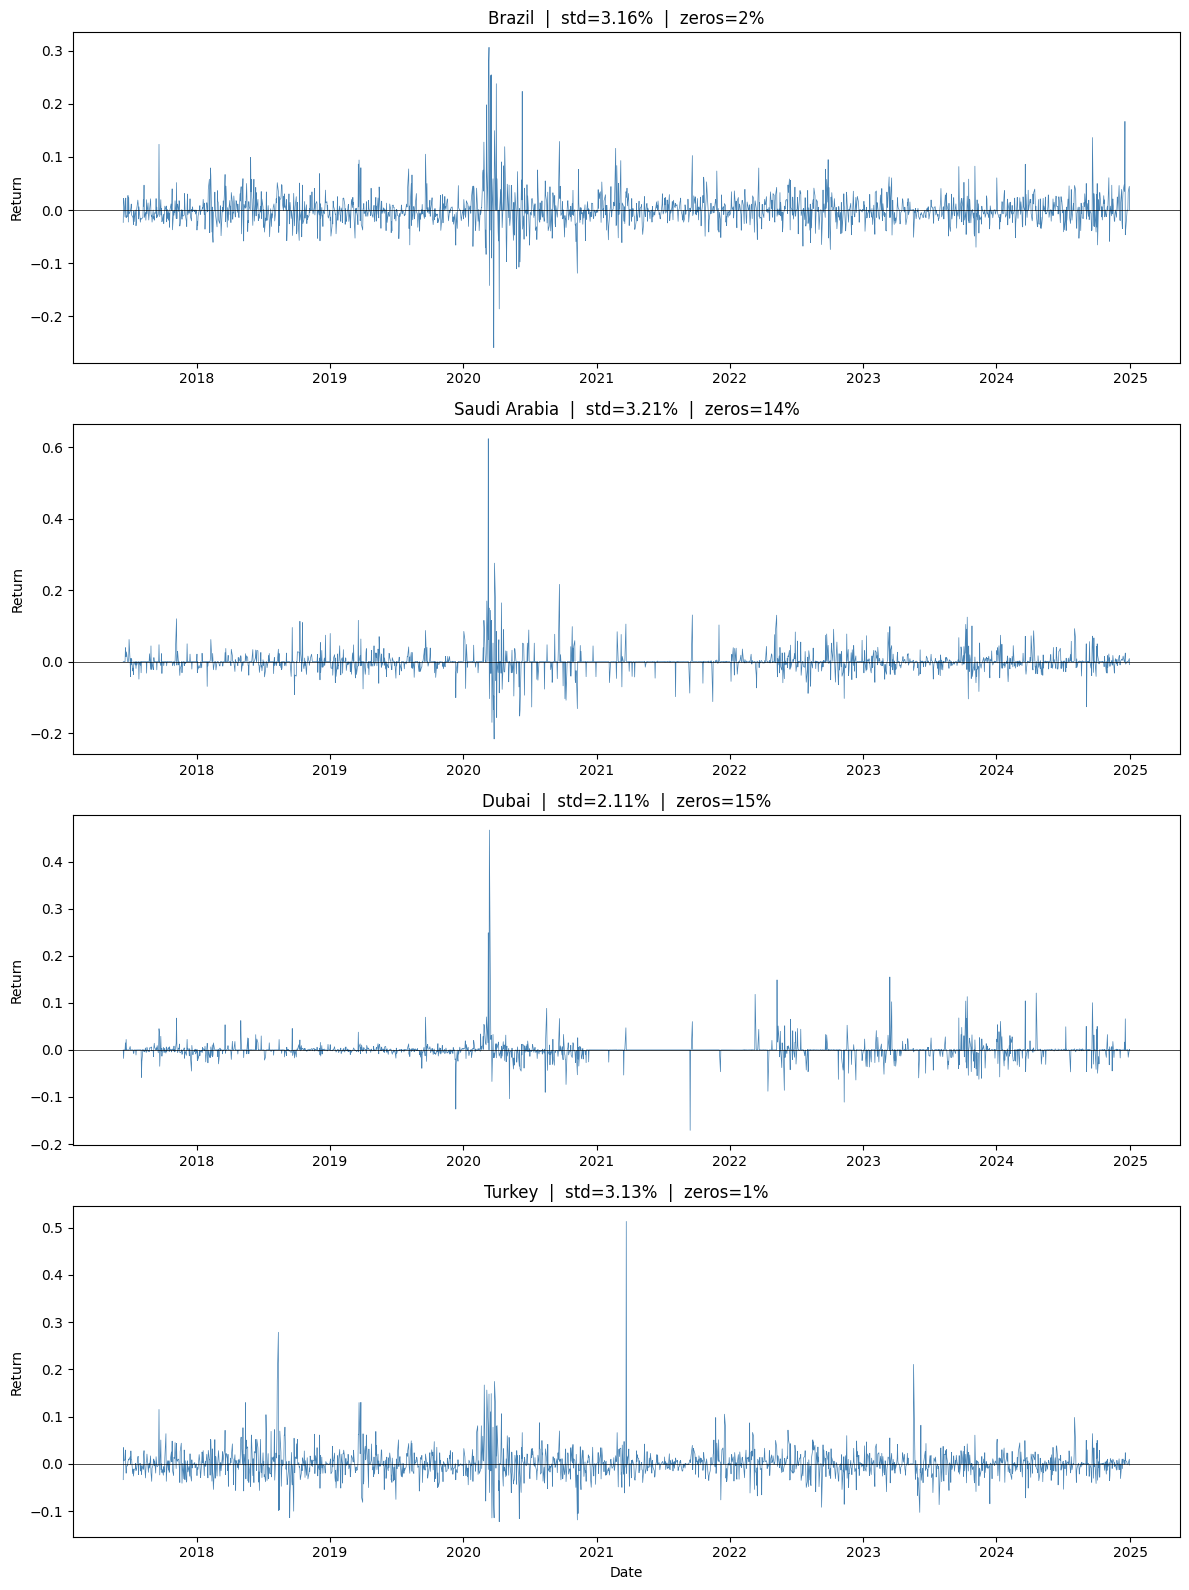

In [61]:
plot_cds_returns(['Brazil','Saudi Arabia','Dubai','Turkey'], cds_returns)

In [63]:
# =============================================================================
# STEP 1: FUNCTION TO GET CONDITIONAL VARIANCES FROM GARCH
# =============================================================================

@njit
def get_garch_variance(params, returns):
    """Extract conditional variance series from GARCH(1,1)"""
    mu, omega, alpha, beta = params
    T = len(returns)
    
    h = np.zeros(T)
    h[0] = np.var(returns)
    
    for t in range(1, T):
        h[t] = omega + alpha * (returns[t-1] - mu)**2 + beta * h[t-1]
    
    return h


def identify_jumps(returns, threshold=2.5):
    """
    Identify jumps using GARCH-standardized residuals.
    Following Gilder et al. (2014) co-exceedance approach.
    
    Returns: Series of boolean jump indicators with same index as returns
    """
    ret = returns.dropna().values
    
    # Estimate GARCH
    garch = estimate_garch(ret)
    
    # Get conditional variances
    h = get_garch_variance(garch['params'], ret)
    
    # Standardized residuals
    mu = garch['params'][0]
    z = (ret - mu) / np.sqrt(h)
    
    # Flag jumps
    jumps = np.abs(z) > threshold
    
    # Return as Series with original index
    return pd.Series(jumps, index=returns.dropna().index, name=returns.name)


# =============================================================================
# STEP 2: IDENTIFY JUMPS IN OIL AND ALL CDS SERIES
# =============================================================================

# Oil jumps
oil_jumps = identify_jumps(brent_returns, threshold=2.5)
print(f"Oil jumps identified: {oil_jumps.sum()} / {len(oil_jumps)} ({oil_jumps.mean()*100:.1f}%)")

# CDS jumps for each country
cds_jumps = {}
for country in cds_returns.columns:
    ret = cds_returns[country].dropna()
    
    # Skip if too few observations or too many zeros
    if len(ret) < 200:
        continue
    zero_pct = (ret == 0).sum() / len(ret)
    if zero_pct > 0.3:
        continue
    
    cds_jumps[country] = identify_jumps(ret, threshold=2.5)
    print(f"{country}: {cds_jumps[country].sum()} jumps ({cds_jumps[country].mean()*100:.1f}%)")


# =============================================================================
# STEP 3: CO-JUMP ANALYSIS
# =============================================================================

def cojump_test(oil_jumps, cds_jumps, country):
    """
    Test for co-jumps between oil and CDS.
    H0: Jumps are independent
    H1: Jumps co-occur more than chance
    """
    # Align dates
    common_idx = oil_jumps.index.intersection(cds_jumps.index)
    oil_j = oil_jumps.loc[common_idx].values
    cds_j = cds_jumps.loc[common_idx].values
    
    n = len(common_idx)
    
    # Contingency table
    a = ((oil_j) & (cds_j)).sum()       # Both jump
    b = ((~oil_j) & (cds_j)).sum()      # Only CDS jumps
    c = ((oil_j) & (~cds_j)).sum()      # Only oil jumps
    d = ((~oil_j) & (~cds_j)).sum()     # Neither jumps
    
    # Expected under independence
    n_oil = oil_j.sum()
    n_cds = cds_j.sum()
    expected = (n_oil / n) * (n_cds / n) * n
    
    # Fisher's exact test
    contingency = [[a, b], [c, d]]
    odds_ratio, fisher_p = fisher_exact(contingency)
    
    # Co-jump rate: P(CDS jump | Oil jump)
    cojump_rate = a / n_oil if n_oil > 0 else np.nan
    
    return {
        'Country': country,
        'N': n,
        'N_oil_jumps': n_oil,
        'N_cds_jumps': n_cds,
        'N_cojumps': a,
        'Expected': expected,
        'Cojump_rate': cojump_rate,
        'Odds_ratio': odds_ratio,
        'Fisher_p': fisher_p
    }


# Run for all countries
cojump_results = []
for country, jumps in cds_jumps.items():
    res = cojump_test(oil_jumps, jumps, country)
    cojump_results.append(res)

cojump_df = pd.DataFrame(cojump_results)
print("\n" + "="*80)
print("CO-JUMP RESULTS")
print("="*80)
print(cojump_df.to_string(index=False))


# =============================================================================
# STEP 4: COMPARE OIL EXPORTERS VS CONTROLS
# =============================================================================

oil_exporters = ['Saudi Arabia', 'Qatar', 'Abu Dhabi', 'Dubai', 'Kuwait', 
                 'Colombia', 'Mexico', 'Brazil', 'Malaysia', 'Indonesia',
                 'Kazakhstan', 'Norway', 'Egypt']

cojump_df['Oil_Exporter'] = cojump_df['Country'].isin(oil_exporters)

print("\n" + "="*80)
print("DIFFERENTIAL CO-JUMP TEST")
print("="*80)
print("\nMean co-jump rate by group:")
print(cojump_df.groupby('Oil_Exporter')[['Cojump_rate', 'Odds_ratio']].mean())

# T-test for difference in co-jump rates
exporters = cojump_df[cojump_df['Oil_Exporter']]['Cojump_rate'].dropna()
controls = cojump_df[~cojump_df['Oil_Exporter']]['Cojump_rate'].dropna()

tstat, ttest_p = ttest_ind(exporters, controls)
print(f"\nT-test for difference in co-jump rates:")
print(f"  Exporters mean: {exporters.mean():.3f}")
print(f"  Controls mean:  {controls.mean():.3f}")
print(f"  t-statistic:    {tstat:.3f}")
print(f"  p-value:        {ttest_p:.4f}")

# Mann-Whitney U test (non-parametric alternative)
ustat, mw_p = mannwhitneyu(exporters, controls, alternative='greater')
print(f"\nMann-Whitney U test (exporters > controls):")
print(f"  U-statistic: {ustat:.1f}")
print(f"  p-value:     {mw_p:.4f}")

Oil jumps identified: 76 / 2870 (2.6%)
United Kingdom: 61 jumps (3.1%)
Japan: 65 jumps (3.3%)
Australia: 65 jumps (3.3%)
China: 52 jumps (2.6%)
Germany: 80 jumps (4.1%)
Italy: 57 jumps (2.9%)
Turkey: 36 jumps (1.8%)
Brazil: 46 jumps (2.3%)
Spain: 59 jumps (3.0%)
Hong Kong: 40 jumps (2.0%)
South Africa: 46 jumps (2.3%)
Mexico: 49 jumps (2.5%)
Indonesia: 55 jumps (2.8%)
Poland: 39 jumps (2.0%)
South Korea: 65 jumps (3.3%)
Egypt: 59 jumps (3.0%)
Colombia: 54 jumps (2.7%)
Thailand: 60 jumps (3.0%)
Malaysia: 58 jumps (2.9%)
Chile: 54 jumps (2.7%)
Vietnam: 66 jumps (3.4%)
Czechia: 52 jumps (2.6%)
Ireland: 78 jumps (4.0%)
Saudi Arabia: 75 jumps (3.8%)
Hungary: 42 jumps (2.1%)
Netherlands: 85 jumps (4.3%)
Philippines: 60 jumps (3.0%)
Romania: 49 jumps (2.5%)
Austria: 71 jumps (3.6%)
Greece: 55 jumps (2.8%)
Belgium: 68 jumps (3.5%)
Qatar: 55 jumps (2.8%)
Peru: 54 jumps (2.7%)
Israel: 46 jumps (2.3%)
Bulgaria: 33 jumps (1.7%)
Bahrain: 23 jumps (1.2%)
Lithuania: 51 jumps (2.6%)
Panama: 58 jumps (